# Synodos — Análise Exploratória

**Painel de acesso hospitalar e perfil de atendimento em saúde mental no SUS**
Challenge FIAP + Oracle 2026 · Turma 1TSCO · Sprint 2

Este notebook percorre a análise que sustenta os indicadores do painel. Ele lê a
camada analítica já integrada — a junção das três fontes (SIH/SUS relacional,
CNES em JSON e CSV do IBGE).

**Pré-requisito:** rode o pipeline antes.

```bash
make amostra && make pipeline
```

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from config import settings
from src.analytics import estilo

estilo.aplicar_estilo()
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print("Ambiente pronto.")

Ambiente pronto.


## 1. Carga da camada analítica

In [2]:
df = pd.read_parquet(settings.PROCESSED_DIR / "analitico_internacoes.parquet")

print(f"Internações: {len(df):,}".replace(",", "."))
print(f"Colunas:     {df.shape[1]}")
print(f"Período:     {df['competencia'].min()} a {df['competencia'].max()}")
print(f"Estados:     {', '.join(sorted(df['sg_uf'].unique()))}")
df.head(3)

Internações: 234.803
Colunas:     38
Período:     202301 a 202412
Estados:     ES, MG, PR, RJ, RS, SC, SP


,nu_aih,ano_competencia,mes_competencia,co_uf_gestor,sg_uf,co_municipio_residencia,co_municipio_internacao,co_cnes,cid_principal,cid_grupo,dt_internacao,dt_saida,qt_dias_permanencia,nu_idade,co_unidade_idade,co_sexo,fl_obito,vl_total_aih,co_carater_internacao,competencia,dt_competencia,ds_sexo,faixa_etaria,fl_permanencia_prolongada,nm_estabelecimento,ds_tipo_unidade,co_tipo_unidade,qt_leitos_sus,co_municipio,nm_uf,regiao,populacao_2022,populacao_regiao,grupo_cid,descricao,descricao_curta,gravidade_relativa,permanencia_esperada_dias
0,202301731664290,2023,1,31,MG,315231,315231,2000861,F15,F15,2023-01-01,2023-01-05,4,37,3,1,0,203.06,02,202301,2023-01-01,Masculino,30-44,0,PRONTO SOCORRO GERAL MG 584,PRONTO SOCORRO GERAL,20,5,315231,Minas Gerais,Sudeste,20538718,84838842,F10-F19,Transtornos mentais devidos ao uso de outros e...,Outros estimulantes,media,10
1,202301912070967,2023,1,31,MG,314411,314411,2000865,F41,F41,2023-01-04,2023-01-09,5,24,3,1,0,282.52,02,202301,2023-01-01,Masculino,18-29,0,PRONTO SOCORRO GERAL MG 632,PRONTO SOCORRO GERAL,20,6,314411,Minas Gerais,Sudeste,20538718,84838842,F40-F48,Outros transtornos ansiosos,Transtorno de ansiedade,baixa,7
2,202301915929111,2023,1,31,MG,311238,311238,2000879,F14,F14,2023-01-24,2023-02-08,15,21,3,1,0,2911.05,02,202301,2023-01-01,Masculino,18-29,0,PRONTO SOCORRO GERAL MG 084,PRONTO SOCORRO GERAL,20,5,311238,Minas Gerais,Sudeste,20538718,84838842,F10-F19,Transtornos mentais e comportamentais devidos ...,Uso de cocaína,alta,13


### Origem de cada bloco de colunas

| Bloco | Fonte | Formato |
|---|---|---|
| `nu_aih`, `cid_*`, `dt_*`, `qt_dias_permanencia`, `vl_total_aih` | SIH/SUS | Relacional |
| `nm_estabelecimento`, `ds_tipo_unidade`, `qt_leitos_sus` | CNES | JSON |
| `nm_uf`, `regiao`, `populacao_2022` | IBGE Censo 2022 | CSV |
| `descricao`, `gravidade_relativa` | CID-10 Cap. V | CSV |

As três fontes convivem em uma única tabela — é o resultado que o Oracle
reproduz em SQL na view `vw_integracao_tres_formatos`.

## 2. Qualidade dos dados

O tratamento registra cada regra aplicada e quantos registros ela removeu.

In [3]:
qualidade = json.loads(
    (settings.PROCESSED_DIR / "relatorio_qualidade.json").read_text(encoding="utf-8")
)

for ds in qualidade["datasets"]:
    print(f"\n{ds['dataset']}")
    print(f"  entrada: {ds['registros_entrada']:,}".replace(",", "."))
    print(f"  saída:   {ds['registros_saida']:,}".replace(",", "."))
    print(f"  aproveitamento: {ds['taxa_aproveitamento_pct']}%")
    for r in ds["regras"]:
        if r["registros_removidos"]:
            print(f"    - {r['regra']}: {r['registros_removidos']} removidos")


sih_internacoes
  entrada: 234.804
  saída:   234.803
  aproveitamento: 100.0%
    - deduplicacao_por_nu_aih: 1 removidos

cnes_estabelecimentos
  entrada: 5.606
  saída:   5.606
  aproveitamento: 100.0%


### Análise de outliers (IQR de Tukey)

Outliers são **documentados, não removidos**: internações psiquiátricas longas são clinicamente reais e são justamente o que mais pressiona a rede.

In [4]:
for variavel, stats in qualidade["analise_outliers"].items():
    print(f"\n{variavel}")
    print(f"  Q1={stats['q1']:.1f}  Q3={stats['q3']:.1f}  IQR={stats['iqr']:.1f}")
    print(f"  limite superior: {stats['limite_superior']:.1f}")
    print(f"  outliers: {stats['qt_outliers']:,} ({stats['pct_outliers']}%)".replace(",", "."))


qt_dias_permanencia
  Q1=9.0  Q3=23.0  IQR=14.0
  limite superior: 44.0
  outliers: 9.672 (4.12%)

vl_total_aih
  Q1=436.4  Q3=1774.8  IQR=1338.4
  limite superior: 3782.4
  outliers: 15.176 (6.46%)


## 3. Estatísticas descritivas

In [5]:
from src.analytics.eda import estatisticas_descritivas

desc = estatisticas_descritivas(df)
desc

,count,mean,std,min,5%,25%,50%,75%,95%,max,assimetria,curtose,cv_pct
qt_dias_permanencia,234803.0,17.67,12.59,1.00,4.00,9.00,15.00,23.0,42.00,149.00,1.67,4.37,71.2
nu_idade,234803.0,38.64,13.66,12.00,15.00,29.00,38.00,48.0,62.00,92.00,0.15,-0.29,35.3
vl_total_aih,234803.0,1380.43,1508.28,0.69,131.76,436.42,907.27,1774.8,4216.01,35354.59,3.12,17.65,109.3


**Leitura:**

- A permanência tem **assimetria positiva** (~1,7): a média supera a mediana,
  puxada por internações longas. Por isso o painel mostra as duas.
- O valor da AIH tem coeficiente de variação acima de 100% — a dispersão de
  custo entre internações é enorme, o que reforça usar mediana em análises
  de custo típico.

## 4. Evolução temporal

In [6]:
serie = pd.read_csv(settings.PROCESSED_DIR / "ind_serie_temporal.csv", sep=";")

crescimento = (serie["qt_internacoes"].iloc[-1] / serie["qt_internacoes"].iloc[0] - 1) * 100
print(f"Primeira competência: {serie['competencia'].iloc[0]} -> {serie['qt_internacoes'].iloc[0]:,} internações".replace(",", "."))
print(f"Última competência:   {serie['competencia'].iloc[-1]} -> {serie['qt_internacoes'].iloc[-1]:,} internações".replace(",", "."))
print(f"Variação no período:  {crescimento:+.1f}%")

serie.head(8)

Primeira competência: 202301 -> 8.227 internações
Última competência:   202412 -> 9.072 internações
Variação no período:  +10.3%


,dt_competencia,competencia,qt_internacoes,permanencia_media,custo_total,obitos,media_movel_3m,variacao_mensal_pct
0,2023-01-01,202301,8227,17.9,11465171.51,91,8227.0,NaN
1,2023-02-01,202302,8693,18.1,12197391.69,99,8460.0,5.66
2,2023-03-01,202303,9476,17.7,13051830.43,101,8798.7,9.01
3,2023-04-01,202304,9853,17.5,13504892.41,105,9340.7,3.98
4,2023-05-01,202305,10581,17.8,14732115.43,129,9970.0,7.39
5,2023-06-01,202306,10467,17.8,14406677.66,116,10300.3,-1.08
6,2023-07-01,202307,10331,17.6,14290200.99,116,10459.7,-1.30
7,2023-08-01,202308,10088,17.6,13991018.89,94,10295.3,-2.35


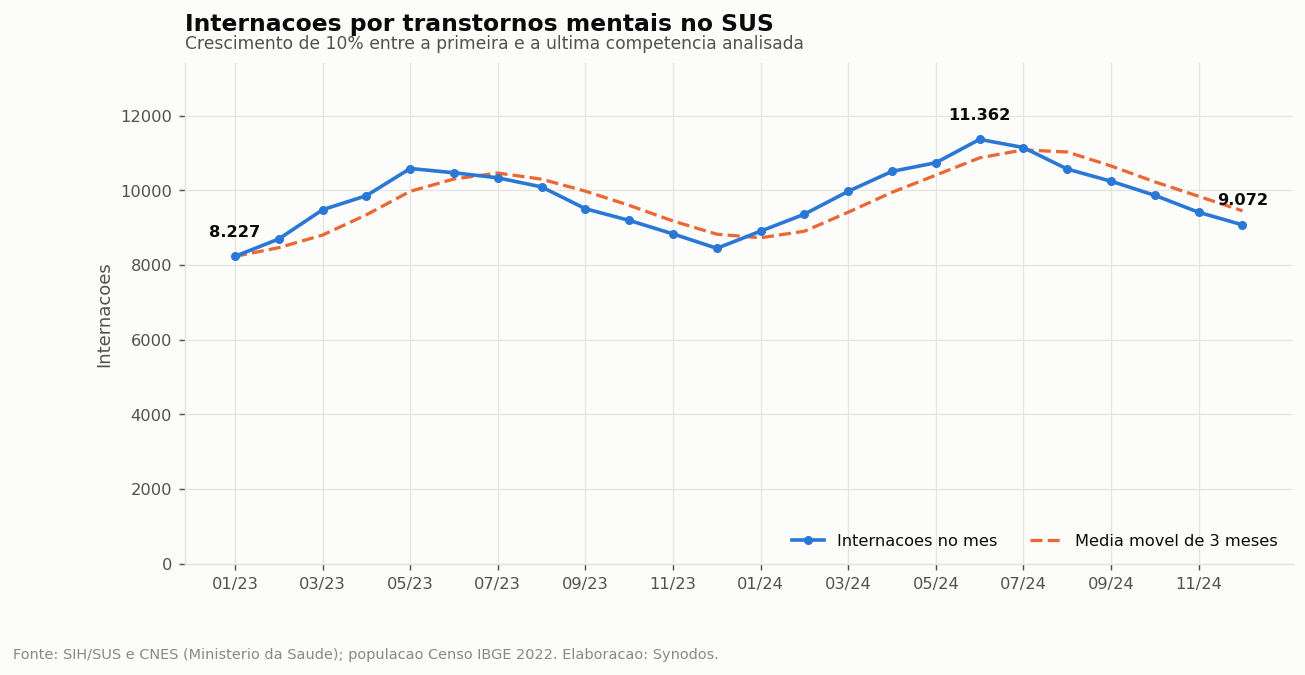

In [7]:
from src.analytics.eda import g_serie_temporal
from IPython.display import Image

Image(str(g_serie_temporal(serie)))

## 5. Perfil diagnóstico — o achado central

O diagnóstico que mais interna **não** é o que mais ocupa leito.

In [8]:
diag = pd.read_csv(settings.PROCESSED_DIR / "ind_perfil_diagnostico.csv", sep=";")

top = diag.nlargest(8, "qt_internacoes")[
    ["cid_grupo", "descricao_curta", "qt_internacoes", "pct_internacoes",
     "permanencia_media", "pct_dias_leito", "indice_carga_leito"]
]
top

,cid_grupo,descricao_curta,qt_internacoes,pct_internacoes,permanencia_media,pct_dias_leito,indice_carga_leito
0,F20,Esquizofrenia,44465,18.94,28.0,30.05,1.59
1,F10,Uso de álcool,43206,18.40,14.0,14.54,0.79
2,F31,Transtorno bipolar,27211,11.59,21.0,13.75,1.19
3,F32,Episódio depressivo,18812,8.01,12.0,5.46,0.68
4,F19,Múltiplas drogas,17561,7.48,16.1,6.83,0.91
5,F33,Depressão recorrente,12916,5.50,14.0,4.35,0.79
6,F14,Uso de cocaína,9461,4.03,13.0,2.97,0.74
7,F29,Psicose não especificada,9405,4.01,20.1,4.55,1.13


A coluna **`indice_carga_leito`** é a razão entre a participação nos dias de
leito e a participação no número de internações:

- **> 1** — o diagnóstico consome leito acima do seu peso em volume
- **< 1** — consome menos leito do que seu volume sugeriria

A esquizofrenia (F20) tem índice ~1,6: responde por 18,9% das internações e
30,1% dos dias de leito. **Dimensionar a rede pelo número de internações
subdimensiona a necessidade real.**

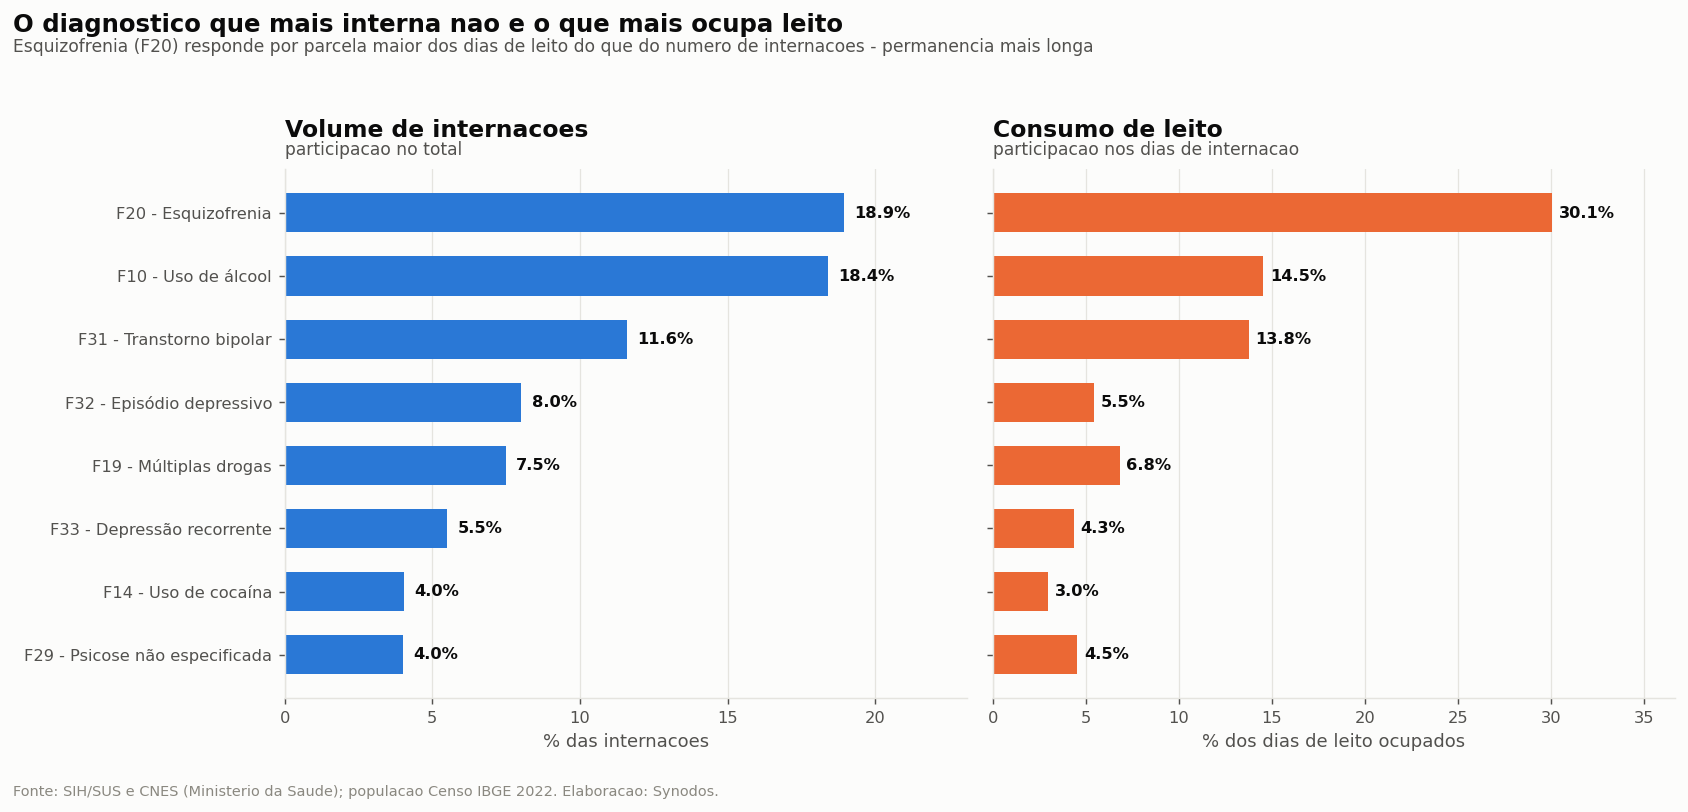

In [9]:
from src.analytics.eda import g_diagnosticos
Image(str(g_diagnosticos(diag)))

## 6. Comparação territorial

Em números absolutos, o estado mais populoso sempre lidera. A taxa por 10 mil habitantes é o que permite comparação justa.

In [10]:
taxas = pd.read_csv(settings.PROCESSED_DIR / "ind_taxa_por_uf.csv", sep=";")

print("Ranking por número ABSOLUTO de internações:")
print(taxas.nlargest(3, "qt_internacoes")[["nm_uf", "qt_internacoes"]].to_string(index=False))

print("\nRanking por internações POR 10 MIL HABITANTES:")
print(taxas.nlargest(3, "internacoes_por_10k_ano")[["nm_uf", "internacoes_por_10k_ano"]].to_string(index=False))

Ranking por número ABSOLUTO de internações:
         nm_uf  qt_internacoes
     São Paulo           96964
  Minas Gerais           38378
Rio de Janeiro           36536

Ranking por internações POR 10 MIL HABITANTES:
            nm_uf  internacoes_por_10k_ano
   Rio de Janeiro                    11.38
        São Paulo                    10.92
Rio Grande do Sul                    10.08


A conclusão muda. É por isso que o denominador populacional do IBGE é fonte de primeira classe na arquitetura, e não um detalhe.

## 7. Correlação entre demanda e capacidade

Usamos Spearman (correlação de postos): com 7 UFs e distribuições assimétricas, ela é mais robusta e não pressupõe linearidade.

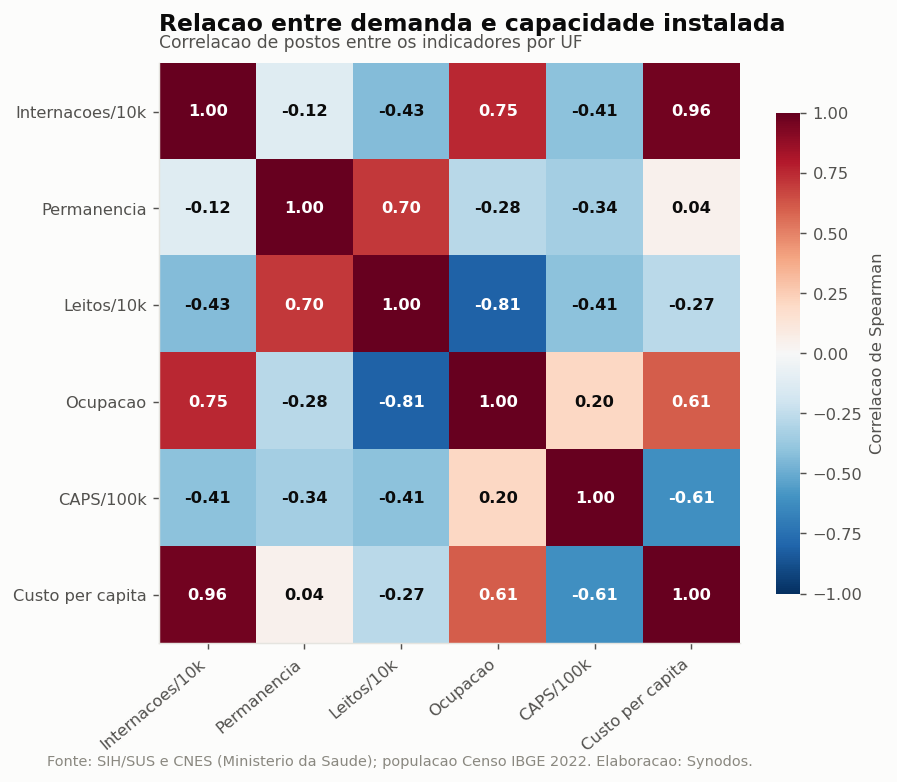

In [11]:
pressao = pd.read_csv(settings.PROCESSED_DIR / "ind_pressao_assistencial.csv", sep=";")

from src.analytics.eda import g_correlacao
caminho, corr = g_correlacao(pressao)
Image(str(caminho))

In [12]:
print("Correlações relevantes (|rho| > 0.5):\n")
for i in range(len(corr)):
    for j in range(i + 1, len(corr)):
        v = corr.iloc[i, j]
        if abs(v) > 0.5:
            print(f"  {corr.index[i]:20s} x {corr.columns[j]:20s} {v:+.2f}")

Correlações relevantes (|rho| > 0.5):

  Internacoes/10k      x Ocupacao             +0.75
  Internacoes/10k      x Custo per capita     +0.96
  Permanencia          x Leitos/10k           +0.70
  Leitos/10k           x Ocupacao             -0.81
  Ocupacao             x Custo per capita     +0.61
  CAPS/100k            x Custo per capita     -0.61


**O achado que sustenta a recomendação do projeto:**

A correlação de **−0,81** entre leitos por 10 mil habitantes e taxa de ocupação
mostra que a escassez não reduz a demanda — apenas empurra a rede para o limite.
Onde há menos leitos, a rede opera mais perto da saturação, e é ali que o
próximo investimento rende mais.

## 8. Índice de Pressão Assistencial (IPA)

Indicador composto criado pelo projeto para responder "onde investir primeiro":

```
IPA = 0,5 × demanda        (internações por 10 mil hab./ano)
    + 0,3 × complexidade   (permanência média)
    + 0,2 × escassez       (inverso dos leitos por 10 mil hab.)
```

Cada dimensão é normalizada por min-max entre as UFs, resultando em uma escala
de 0 a 100 comparável entre estados de tamanhos muito diferentes.

In [13]:
pressao[["ranking", "nm_uf", "regiao", "indice_pressao", "classificacao",
         "n_demanda", "n_complexidade", "n_escassez"]].sort_values("ranking")

,ranking,nm_uf,regiao,indice_pressao,classificacao,n_demanda,n_complexidade,n_escassez
0,1,Rio de Janeiro,Sudeste,70.0,Alta,100.0,0.0,100.0
1,2,São Paulo,Sudeste,66.1,Alta,82.1,50.0,50.0
2,3,Rio Grande do Sul,Sul,54.7,Alta,49.4,100.0,0.0
3,4,Espírito Santo,Sudeste,30.0,Moderada,0.0,100.0,0.0
4,5,Santa Catarina,Sul,15.6,Baixa,15.2,0.0,40.0
5,6,Paraná,Sul,14.6,Baixa,1.2,0.0,70.0
6,7,Minas Gerais,Sudeste,13.3,Baixa,20.6,0.0,15.0


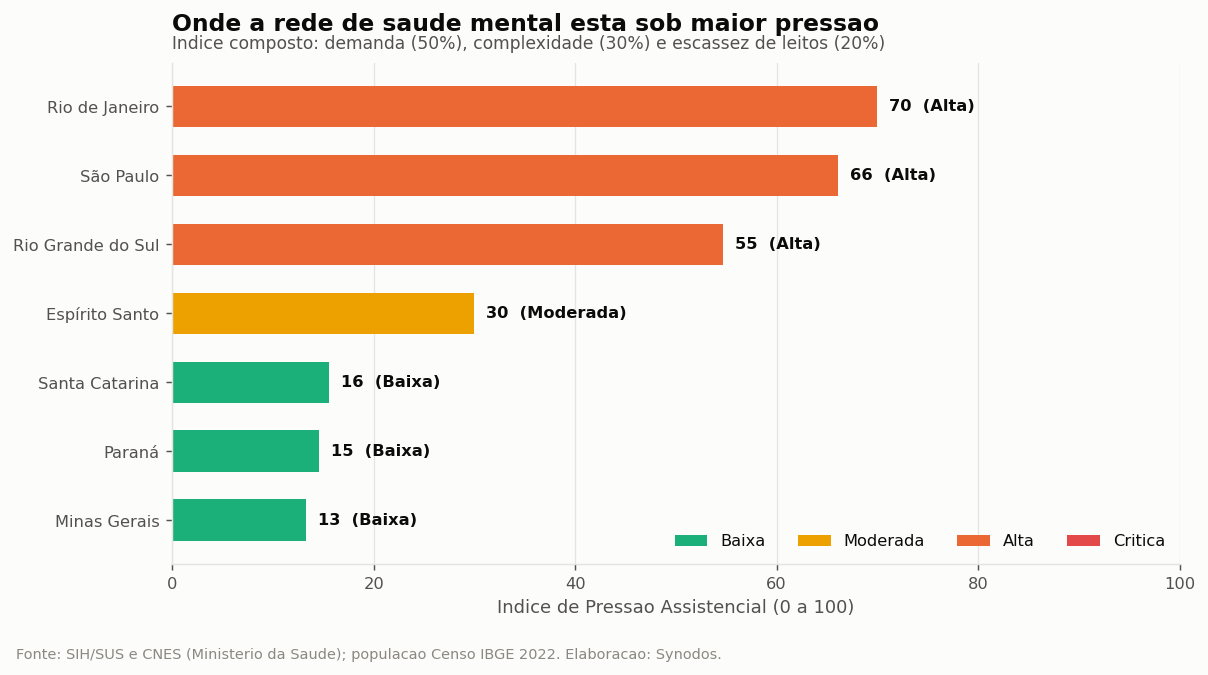

In [14]:
from src.analytics.eda import g_pressao
Image(str(g_pressao(pressao)))

## 9. Modelos analíticos

### 9.1 Clusterização de estados (K-Means)

Agrupa UFs por perfil assistencial. O número de grupos é escolhido pelo coeficiente de silhueta, não arbitrado.

In [15]:
from src.analytics.modelos import clusterizar, g_clusters

clusters, info = clusterizar(pressao)

print("Silhueta por número de grupos:")
for k, s in info["diagnostico"]["silhueta_por_k"].items():
    marca = "  <- escolhido" if int(k) == info["diagnostico"]["k_escolhido"] else ""
    print(f"  k={k}: {s}{marca}")

print()
info["perfis"]

2026-08-31 19:00:29,846 | INFO    |   k=2 -> silhueta 0.301


2026-08-31 19:00:29,858 | INFO    |   k=3 -> silhueta 0.325


2026-08-31 19:00:29,870 | INFO    |   k=4 -> silhueta 0.397


2026-08-31 19:00:29,882 | INFO    |   k=5 -> silhueta 0.306


2026-08-31 19:00:29,884 | INFO    | k escolhido: 4 (silhueta 0.397)


Silhueta por número de grupos:
  k=2: 0.301
  k=3: 0.325
  k=4: 0.397  <- escolhido
  k=5: 0.306



,internacoes_por_10k_ano,permanencia_media,leitos_por_10k_hab,taxa_ocupacao_pct,caps_por_100k_hab,indice_pressao,ufs
perfil,,,,,,,
Grupo 4,9.27,17.60,0.84,53.50,1.33,14.45,"SC, MG"
Rede equilibrada,8.84,17.60,0.75,57.00,1.34,14.60,PR
Rede sob pressao,11.15,17.65,0.74,73.65,1.33,68.05,"RJ, SP"
Situacao intermediaria,9.44,17.80,0.89,51.95,1.33,42.35,"RS, ES"


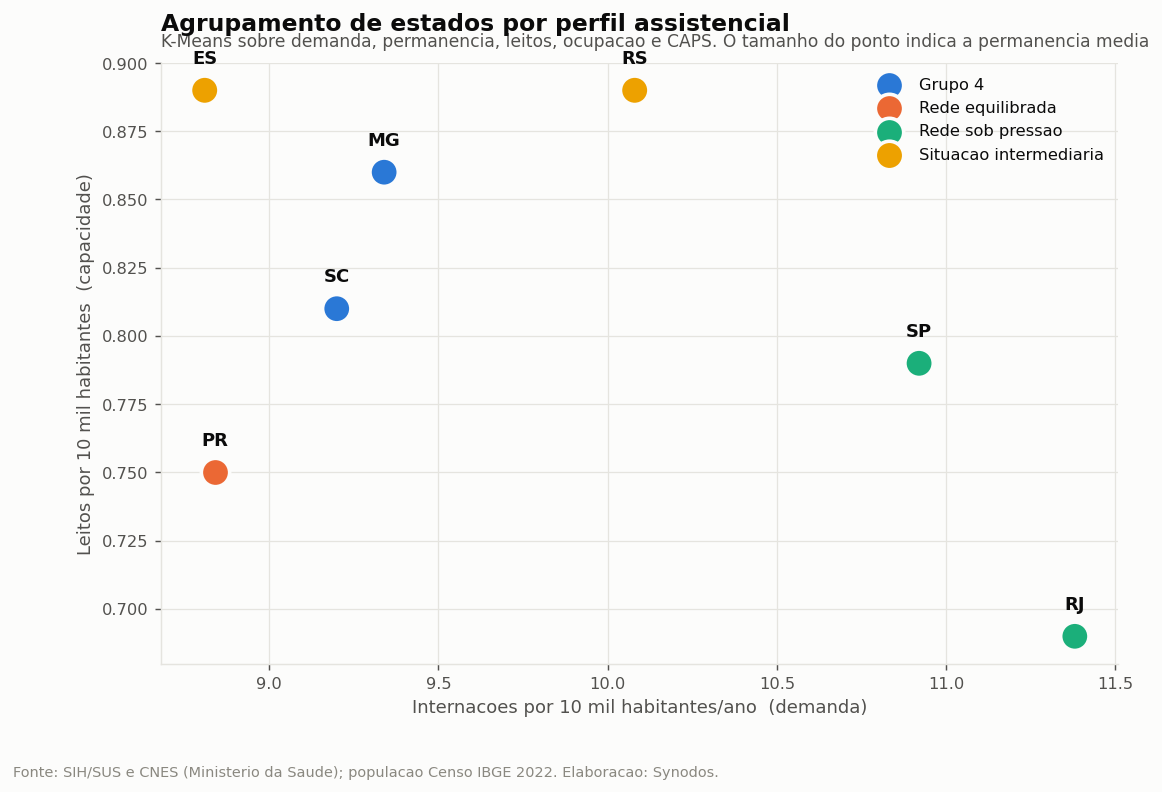

In [16]:
Image(str(g_clusters(clusters)))

### 9.2 Projeção de demanda

Regressão com tendência linear e sazonalidade mensal (dummies). Validada em uma janela de 6 meses retidos do treino.

In [17]:
from src.analytics.modelos import projetar_demanda, g_projecao

projecao, info_proj = projetar_demanda(serie)

m = info_proj["metricas"]
print(f"R²:                        {m['r2']:.4f}")
print(f"MAPE na validação:         {m['mape_validacao_pct']}%")
print(f"Tendência:                 {m['tendencia_por_mes']:+.1f} internações/mês")
print(f"Tendência anualizada:      {m['tendencia_anualizada_pct']:+.1f}%")
print(f"Crescimento ano contra ano projetado: {m['crescimento_yoy_projetado_pct']:+.1f}%")
print()
projecao

2026-08-31 19:00:30,150 | INFO    | Validacao em 6 meses retidos: MAPE 0.98%


2026-08-31 19:00:30,153 | INFO    | Modelo final: R2 0.988 | tendencia +51.7 internacoes/mes


R²:                        0.9883
MAPE na validação:         0.98%
Tendência:                 +51.7 internações/mês
Tendência anualizada:      +6.3%
Crescimento ano contra ano projetado: +6.3%



,competencia,previsto,limite_inferior,limite_superior
0,202501,9495.0,9234.0,9756.0
1,202502,9955.0,9694.0,10216.0
2,202503,10653.0,10392.0,10914.0
3,202504,11108.0,10848.0,11369.0
4,202505,11588.0,11327.0,11849.0
5,202506,11844.0,11584.0,12105.0


> **Atenção metodológica.** As duas métricas de crescimento convergem em ~6,3%,
> e recuperam a taxa real embutida nos dados — é uma validação do modelo.
>
> Mas o **R² de 0,99 e o MAPE de 1,0% não são realistas**. Eles refletem a
> regularidade dos dados de amostra, que têm ruído de Poisson bem menor que a
> variabilidade do SIH real. Com dados oficiais, espere R² entre 0,70 e 0,85.

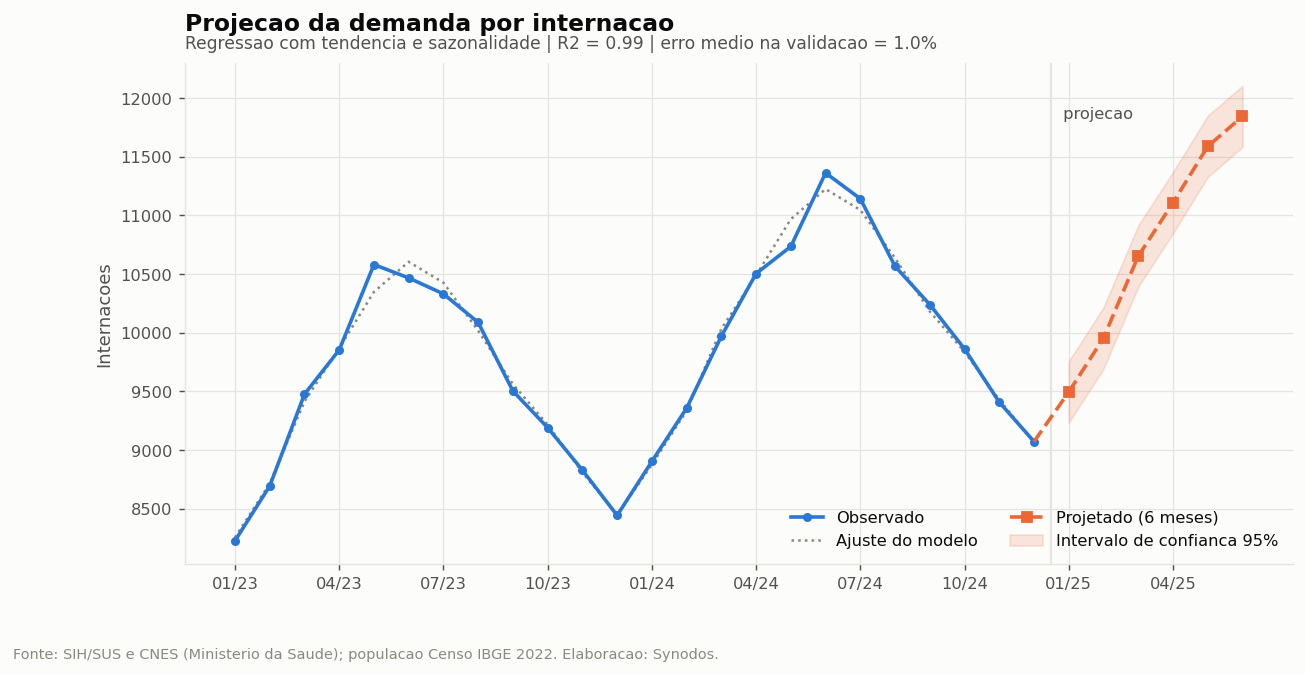

In [18]:
Image(str(g_projecao(serie, projecao, info_proj["ajustado"], info_proj["metricas"])))

### 9.3 Decomposição sazonal (STL)

Separa a série em tendência, componente sazonal e resíduo — responde se o crescimento observado é real ou efeito de sazonalidade.

Força da tendência:    1.0
Força da sazonalidade: 1.0
Pico sazonal:  Jun
Vale sazonal:  Dez


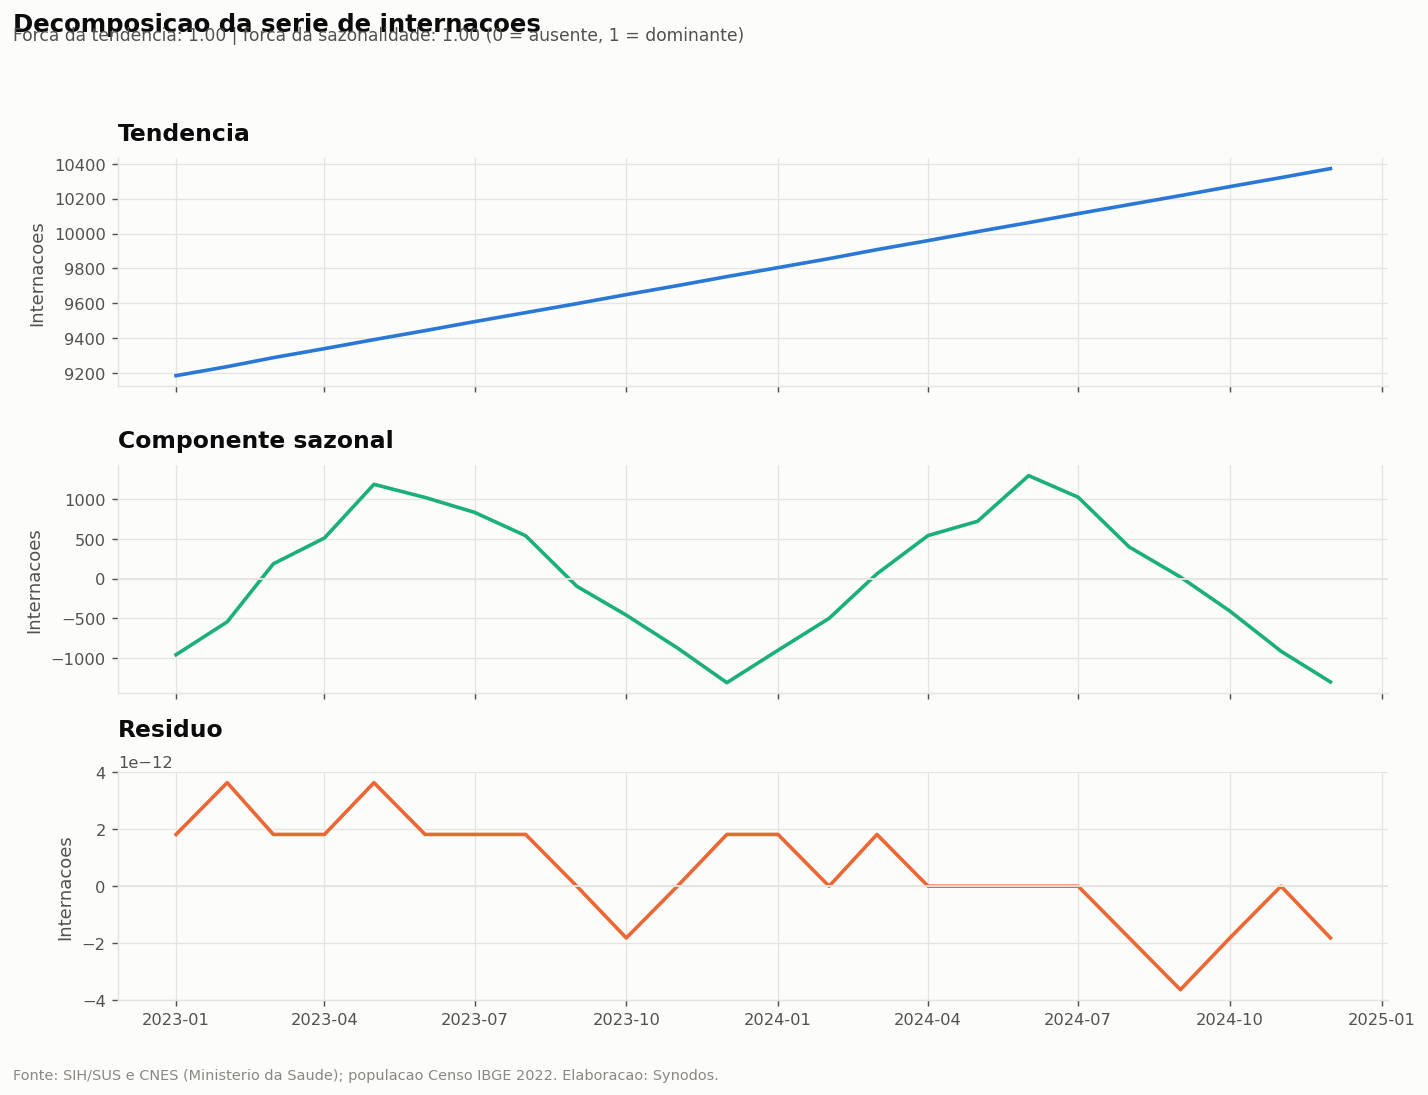

In [19]:
from src.analytics.modelos import g_decomposicao

caminho_decomp, metricas_decomp = g_decomposicao(serie)

meses = ["", "Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
         "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
print(f"Força da tendência:    {metricas_decomp['forca_tendencia']}")
print(f"Força da sazonalidade: {metricas_decomp['forca_sazonalidade']}")
print(f"Pico sazonal:  {meses[metricas_decomp['mes_pico_sazonal']]}")
print(f"Vale sazonal:  {meses[metricas_decomp['mes_vale_sazonal']]}")

Image(str(caminho_decomp))

## 10. Perguntas em linguagem natural

A mesma interface que o dashboard usa. Em produção, o Oracle Select AI ocupa esse lugar.

In [20]:
from src.db.select_ai import perguntar

for p in [
    "Quais estados estão com maior pressão assistencial?",
    "Quais os cinco transtornos que mais consomem dias de leito?",
    "Qual estado tem menos leitos por habitante?",
]:
    r = perguntar(p, forcar_local=True)
    print("=" * 78)
    print(f"PERGUNTA: {p}")
    print(f"SQL:      {r['sql'][:110]}...")
    print(f"\n{r['narrativa']}\n")

PERGUNTA: Quais estados estão com maior pressão assistencial?
SQL:      SELECT ranking, nm_uf AS estado, regiao, indice_pressao, classificacao, internacoes_por_10k_ano, permanencia_m...

O estado sob maior pressao assistencial e Rio de Janeiro (Sudeste), com indice 70.0 (Alta): 11.38 internacoes por 10 mil habitantes/ano, permanencia media de 17.6 dias e apenas 0.69 leitos por 10 mil habitantes.

PERGUNTA: Quais os cinco transtornos que mais consomem dias de leito?
SQL:      SELECT cid_grupo AS cid, descricao, qt_internacoes, pct_internacoes, permanencia_media, pct_dias_leito, indice...

O diagnostico mais frequente e Esquizofrenia (F20), com 18.94% das internacoes e permanencia media de 28.0 dias.

PERGUNTA: Qual estado tem menos leitos por habitante?
SQL:      SELECT sg_uf AS estado, qt_leitos, qt_caps, qt_estabelecimentos, taxa_ocupacao_pct, leitos_por_10k_hab, caps_p...

RJ apresenta a maior ocupacao estimada: 80.0%, com 1.102 leitos e 214 CAPS.



## 11. Conclusões

1. **A esquizofrenia (F20) consome 30,1% dos dias de leito com 18,9% das
   internações.** Planejar capacidade por volume de internação subdimensiona a
   necessidade real da rede.

2. **Rio de Janeiro lidera o Índice de Pressão Assistencial (70, "Alta")** —
   maior demanda proporcional combinada com a menor densidade de leitos entre
   as UFs analisadas.

3. **Correlação de −0,81 entre leitos por habitante e taxa de ocupação.** A
   escassez de leitos não reduz a demanda; empurra a rede para o limite.

4. **Tendência de crescimento de ~6,3% ao ano**, consistente entre a regressão
   e a comparação ano contra ano, com pico sazonal no meio do ano.

### Próximos passos

- Provisionar o Oracle Autonomous Database e executar `sql/01` a `sql/05`
- Ativar o Select AI com modelo de linguagem real
- Descer a granularidade de UF para município (o campo já é carregado)
- Adicionar mapa coroplético com a malha territorial do IBGE